## 2.4 파이토치 코드 맛보기

[칼럼]
1. price
2. maint
3. doors
4. persons
5. lug_capacity
6. safety
7. output(차 상태)

In [15]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
dataset = pd.read_csv('/content/drive/MyDrive/data/딥러닝 파이토치 교과서/car_evaluation.csv')
dataset.head()

,price,maint,doors,persons,lug_capacity,safety,output
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


<Axes: ylabel='count'>

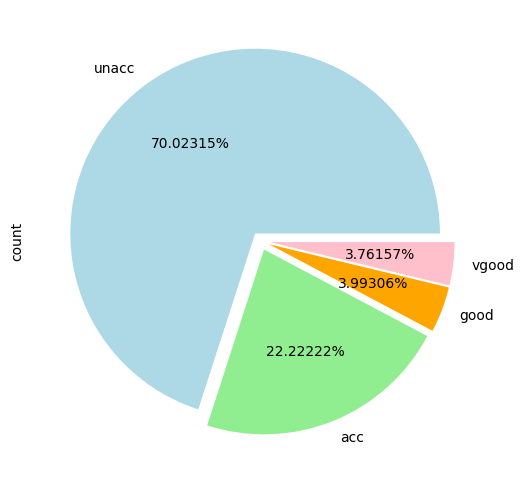

In [4]:
# 분포 형태로 시각화
fig_size = plt.rcParams['figure.figsize']
fig_size[0] = 8
fig_size[1] = 6
plt.rcParams['figure.figsize'] = fig_size
dataset.output.value_counts().plot(kind='pie', autopct='%0.05f%%',
                                   colors = ['lightblue', 'lightgreen', 'orange', 'pink'],
                                   explode=(0.05,0.05,0.05,0.05))

결과에 따르면 대부분의 자동차는 허용 불가능한 상태에 있고 20%만 허용 가능한 수준이다. 즉, 양호한 상태의 자동차 비율이 매우 낮은 것을 볼 수 있음.

딥러닝은 통계 알고리즘을 기반으로 하기 떄문에 단어를 숫자로 변환해야 한다. 가장 먼저 필요한 전처리는 데이터를 파악하는 것이다. 주어진 데이터의 형태를 파악한 후 숫자로 변환해 주어야 하는데, 예제 데이터는 모두 범주형 데이터로 구성되어 있다.

데이터 전처리를 먼저 해줘야 한다. 먼저 astype() 메서드를 이용하여 범주 특성을 갖는 데이터를 범주형 타입으로 변환한다.

In [5]:
categorical_columns = ['price', 'maint', 'doors', 'persons', 'lug_capacity', 'safety']

for category in categorical_columns:
  dataset[category] = dataset[category].astype('category')
  # astype() 메서드를 이용하여 데이터를 범주형으로 변환

price = dataset['price'].cat.codes.values
maint = dataset['maint'].cat.codes.values
doors = dataset['doors'].cat.codes.values
persons = dataset['persons'].cat.codes.values
lug_capacity = dataset['lug_capacity'].cat.codes.values
safety = dataset['safety'].cat.codes.values

categorical_data = np.stack([price, maint, doors, persons, lug_capacity, safety], 1)
categorical_data[:10]

array([[3, 3, 0, 0, 2, 1],
       [3, 3, 0, 0, 2, 2],
       [3, 3, 0, 0, 2, 0],
       [3, 3, 0, 0, 1, 1],
       [3, 3, 0, 0, 1, 2],
       [3, 3, 0, 0, 1, 0],
       [3, 3, 0, 0, 0, 1],
       [3, 3, 0, 0, 0, 2],
       [3, 3, 0, 0, 0, 0],
       [3, 3, 0, 1, 2, 1]], dtype=int8)

1. 범주형 데이터를 텐서로 변환하기 위해 다음과 같은 절차 필요

[범주형 데이터] -> [dataset[category]] -> 넘파이 배열 -> 텐서

범주형 데이터를 숫자로 변환하기 위해 cat.codes를 사용. cat.codes는 어떤 클래스가 어떤 숫자로 매핑되어 있는지 확인이 어려운 단점이 있음.

2. np.stack은 두 개 이상의 넘파이 객체를 합칠 때 사용

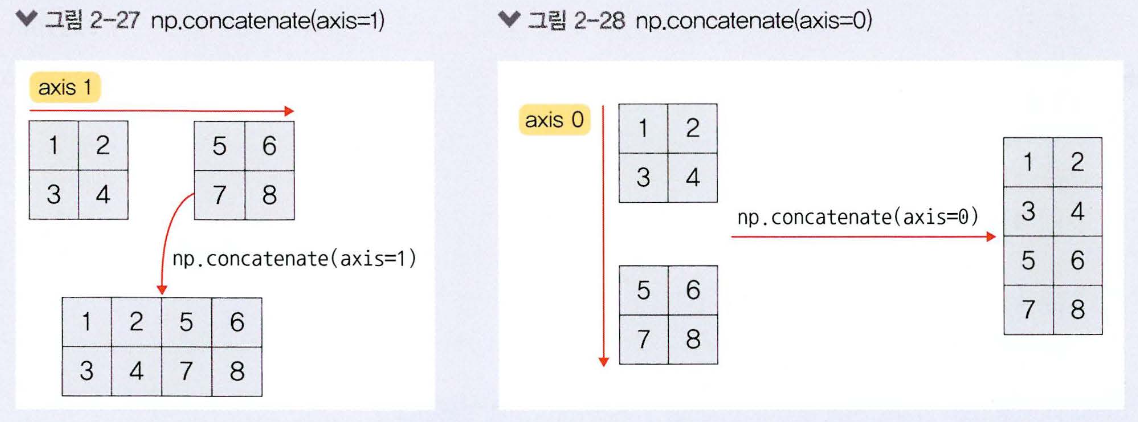

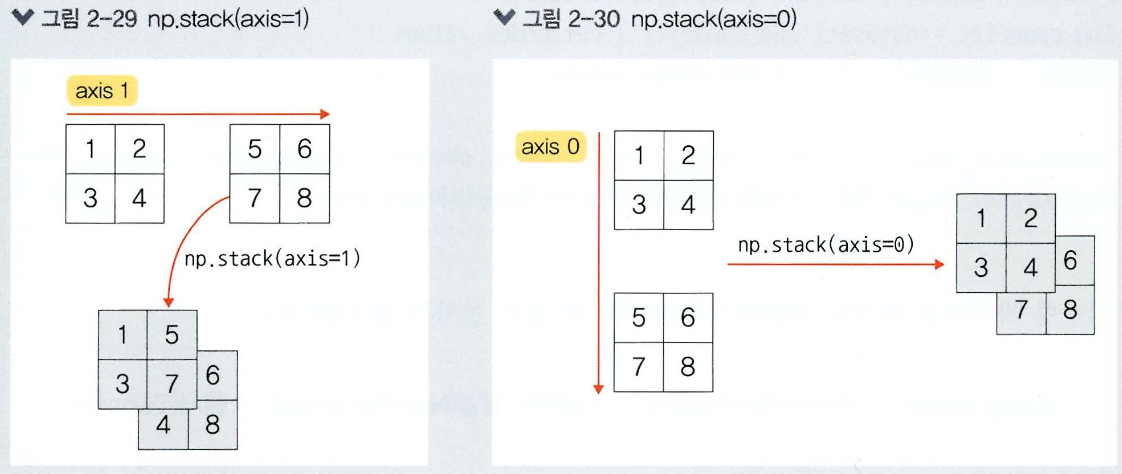

In [7]:
# 배열을 텐서로 변환
categorical_data = torch.tensor(categorical_data, dtype=torch.int64)
categorical_data[:10]

/tmp/ipython-input-1294601444.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  categorical_data = torch.tensor(categorical_data, dtype=torch.int64)


tensor([[3, 3, 0, 0, 2, 1],
        [3, 3, 0, 0, 2, 2],
        [3, 3, 0, 0, 2, 0],
        [3, 3, 0, 0, 1, 1],
        [3, 3, 0, 0, 1, 2],
        [3, 3, 0, 0, 1, 0],
        [3, 3, 0, 0, 0, 1],
        [3, 3, 0, 0, 0, 2],
        [3, 3, 0, 0, 0, 0],
        [3, 3, 0, 1, 2, 1]])

In [8]:
# 레이블로 사용할 칼럼을 텐서로 변환
outputs = pd.get_dummies(dataset.output)
outputs = outputs.values
outputs = torch.tensor(outputs).flatten() # 1차원 텐서로 변환

print(categorical_data.shape)
print(outputs.shape)

torch.Size([1728, 6])
torch.Size([6912])


- get_dummies: 가변수로 만들어 주는 함수. 가변수로 만든다는 것은 문자를 숫자 (0,1)로 바꿔주는 의미.

<ravel(), reshape(), flatten()>
- 2차원 텐서가 1차원으로 변경되어 출력

In [12]:
a = np.array([[1,2],
             [3,4]])
print(a.ravel())
print(a.reshape(-1))
print(a.flatten())

[1 2 3 4]
[1 2 3 4]
[1 2 3 4]


워드 임베딩은 유사한 단어끼리 유사하게 인코딩되도록 표현하는 방법이다. 또한 높은 차원의 임베딩일수록 단어 간의 세부적인 관계를 잘 파악할 수 있다. 배열을 N차원으로 변환하기 위해 먼저 모든 범주형 칼럼에 대한 임베딩 크기를 정의한다. 임베딩 크기에 대한 규칙은 없지만 칼럼의 고유 값 수를 2로 나누는 것을 많이 사용한다.

In [13]:
# 범주형 칼럼을 N차원으로 변환
categorical_column_size = [len(dataset[column].cat.categories) for column in
                           categorical_columns]
categorical_embedding_sizes = [(col_size, min(50,(col_size+1)//2)) for col_size in
                               categorical_column_size]

print(categorical_embedding_sizes)

[(4, 2), (4, 2), (4, 2), (3, 2), (3, 2), (3, 2)]


In [14]:
# 데이터셋 분리
total_records = 1728
test_records = int(total_records * .2)

categorical_train_data = categorical_data[:total_records-test_records]
categorical_test_data = categorical_data[total_records-test_records:total_records]
train_outputs = outputs[:total_records - test_records]
test_outputs = outputs[total_records - test_records:total_records]

In [16]:
# 데이터셋 분리 확인
print(len(categorical_train_data))
print(len(train_outputs))
print(len(categorical_test_data))
print(len(test_outputs))

1383
1383
345
345


In [17]:
# 모델의 네트워크 생성
class Model(nn.Module):
  def __init__(self, embedding_size, output_size, layers, p=0.4):
    super().__init__()
    self.all_embeddings = nn.ModuleList([nn.Embedding(ni,nf) for ni,
                                         nf in embedding_size])

    self.embedding_dropout = nn.Dropout(p)
    all_layers = []
    num_categorical_cols = sum((nf for ni, nf in embedding_size))
    input_size = num_categorical_cols

    for i in layers:
      all_layers.append(nn.Linear(input_size, i))
      all_layers.append(nn.ReLU(inplace=True))
      all_layers.append(nn.BatchNorm1d(i))
      all_layers.append(nn.Dropout(p))
      input_size = i

    all_layers.append(nn.Linear(layers[-1], output_size))
    self.layers = nn.Sequential(*all_layers)

  def forward(self, x_categorical):
    embeddings = []
    for i, e in enumerate(self.all_embeddings):
      embeddings.append(e(x_categorical[:,i]))
    x = torch.cat(embeddings, 1)
    x = self.embedding_dropout(x)
    x = self.layers(x)
    return x

1. 클래스 형태로 구현되는 모델은 nn.Module을 상속받음
2. __init__()은 모델에서 사용될 파라미터와 신경망을 초기화하기 위한 용도로 사용. 객체가 생성될 때 자동으로 호출
3. super().__init__()은 부모 클래스에 접근할 때 사용
4. 모델의 네트워크 계층을 구축하기 위해 for문을 이용하여 각 계층을 all_layers목록에 추가
  - Linear: 선형 계층은 입력 데이터에 선형 변환을 진행한 결과
  - ReLU: 활성화 함수
  - BatchNorm1d: 배치 정규화 용도로 사용
  - Dropout: 과적합 방지에 사용

In [18]:
# Model 클래스의 객체 생성
model = Model(categorical_embedding_sizes, 4, [200,100,50], p=0.4)
print(model)

Model(
  (all_embeddings): ModuleList(
    (0-2): 3 x Embedding(4, 2)
    (3-5): 3 x Embedding(3, 2)
  )
  (embedding_dropout): Dropout(p=0.4, inplace=False)
  (layers): Sequential(
    (0): Linear(in_features=12, out_features=200, bias=True)
    (1): ReLU(inplace=True)
    (2): BatchNorm1d(200, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=200, out_features=100, bias=True)
    (5): ReLU(inplace=True)
    (6): BatchNorm1d(100, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Dropout(p=0.4, inplace=False)
    (8): Linear(in_features=100, out_features=50, bias=True)
    (9): ReLU(inplace=True)
    (10): BatchNorm1d(50, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): Dropout(p=0.4, inplace=False)
    (12): Linear(in_features=50, out_features=4, bias=True)
  )
)


모델을 훈련시키기 전에 손실 함수와 옵티마이저에 대해 정의해야 한다. 이번 예제는 데이터를 분류하는 것이므로 크로스 엔트로피 손실 함수를 사용한다. 옵티마이저로는 아담을 사용한다.

In [19]:
# 모델의 파라미터 정의
loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [21]:
# CPU/GPU 사용 지정
if torch.cuda.is_available():
  device = torch.device('cuda')
else:
  device = torch.device('cpu')

In [22]:
# 모델 학습
epochs = 500
aggregated_losses = []
train_outputs = train_outputs.to(device=device, dtype=torch.int64)

for i in range(epochs):
  i += 1
  y_pred = model(categorical_train_data).to(device)
  single_loss = loss_function(y_pred, train_outputs)
  aggregated_losses.append(single_loss)

  if i%25 ==1:
    print(f'epoch:{i:3} loss: {single_loss.item():10.8f}')

  optimizer.zero_grad()
  single_loss.backward()
  optimizer.step()

print(f'epoch: {i:3} loss: {single_loss.item(): 10.10f}')

epoch:  1 loss: 1.61915529
epoch: 26 loss: 1.41980660
epoch: 51 loss: 1.34085727
epoch: 76 loss: 1.23659623
epoch:101 loss: 1.07168913
epoch:126 loss: 0.92987013
epoch:151 loss: 0.83251309
epoch:176 loss: 0.73615509
epoch:201 loss: 0.69489390
epoch:226 loss: 0.63255602
epoch:251 loss: 0.62566370
epoch:276 loss: 0.62213248
epoch:301 loss: 0.59581065
epoch:326 loss: 0.60327154
epoch:351 loss: 0.59550703
epoch:376 loss: 0.58673400
epoch:401 loss: 0.58141190
epoch:426 loss: 0.58227557
epoch:451 loss: 0.57641739
epoch:476 loss: 0.57666600
epoch: 500 loss:  0.5691717267


In [23]:
# 테스트 데이터셋으로 모델 예측
test_outputs = test_outputs.to(device=device, dtype=torch.int64)

with torch.no_grad():
  y_val = model(categorical_test_data)
  loss = loss_function(y_val, test_outputs)
print(f'Loss: {loss:.8f}')

Loss: 0.55639875


In [24]:
# 모델의 예측 확인
print(y_val[:5])

tensor([[ 2.3369,  1.4445, -2.7443, -3.1606],
        [-0.3193, -0.2035, -2.7554, -2.2533],
        [ 2.6186,  1.4095, -2.9076, -3.3886],
        [ 2.9959,  1.9729, -3.9588, -4.4367],
        [ 1.8082,  0.9771, -2.5439, -2.6010]])


In [25]:
# 가장 큰 값을 갖는 인덱스 확인
y_val = np.argmax(y_val, axis=1)
print(y_val[:5])

tensor([0, 1, 0, 0, 0])


In [26]:
# 테스트 데이터셋을 이용한 정확도 계산
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print(confusion_matrix(test_outputs, y_val))
print(classification_report(test_outputs, y_val))
print(accuracy_score(test_outputs, y_val))

[[258   1]
 [ 86   0]]
              precision    recall  f1-score   support

           0       0.75      1.00      0.86       259
           1       0.00      0.00      0.00        86

    accuracy                           0.75       345
   macro avg       0.38      0.50      0.43       345
weighted avg       0.56      0.75      0.64       345

0.7478260869565218


[분류 모델의 성능 평가 지표]

(용어)
- True Positive: 모델이 1이라고 예측했는데 실제 값도 1인 경우
- True Negative: 모델이 0이라고 예측했는데 실제 값도 0인 경우
- False Positive: 모델이 1이라고 예측했는데 실제 값은 0인 경우. Type 1 error
- False Negative: 모델이 0이라고 예측했는데 실제 값은 1인 경우, Type 2 error

<정확도>
- 전체 예측 건수에서 정답을 맞힌 건수의 비율

<재현율>
- 실제로 정답이 1이라고 할 때 모델도 1로 예측한 비율

<정밀도>
- 모델이 1이라고 예측한 것 중에서 실제로 정답이 1인 비율

<F1-스코어>
- 일반적으로 정밀도와 재현율은 트레이드 오프 관계
- 이를 해결하기 위해 정밀도와 재현율의 조화 평균을 이용한 것